# Experiment 6 — RNN / LSTM / GRU, Sequence Learning & Video Understanding
CS3807 — Deep Learning Laboratory

Runs end-to-end in Google Colab (**Runtime → Change runtime type → GPU** recommended).

Produces every result the lab report needs: dataset stats, preprocessing shapes,
the numerical RNN exercise, trained RNN/LSTM/GRU (curves, confusion matrices,
classification reports), the sequence-length study, CNN(MobileNetV2)+LSTM/GRU
video classification on a real UCF101 5-class subset (synthetic fallback only
if the download is genuinely unreachable), and the Seq2Seq reversal task.

At the end, everything is saved to `results/summary.json` + `results/figures/`
and zipped for download.

In [17]:
!pip -q install remotezip tqdm opencv-python-headless seaborn scikit-learn datasets > /dev/null
print("Dependencies installed.")

Dependencies installed.


In [18]:
import os, json, time, random, pathlib, collections, zipfile, shutil
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import remotezip as rz
import tqdm

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, classification_report,
                              precision_recall_fscore_support, accuracy_score)

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

RESULTS_DIR = Path("results"); FIG_DIR = RESULTS_DIR / "figures"; DATA_DIR = Path("data")
for d in [RESULTS_DIR, FIG_DIR, DATA_DIR]:
    d.mkdir(parents=True, exist_ok=True)

ACTIVITIES = ["WALKING", "WALKING_UPSTAIRS", "WALKING_DOWNSTAIRS",
              "SITTING", "STANDING", "LAYING"]
CHANNELS = ["body_acc_x","body_acc_y","body_acc_z",
            "body_gyro_x","body_gyro_y","body_gyro_z",
            "total_acc_x","total_acc_y","total_acc_z"]

BATCH_SIZE, EPOCHS, LEARNING_RATE = 32, 30, 1e-3
SUMMARY = {}
print("GPU available:", tf.config.list_physical_devices('GPU'))

GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [19]:
HAR_URL = "https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip"
HAR_ROOT = DATA_DIR / "UCI_HAR"
SIGNAL_FILES = CHANNELS

def download_har():
    zip_path = DATA_DIR / "har.zip"
    target = HAR_ROOT / "UCI HAR Dataset"
    if not target.exists():
        print("Downloading UCI HAR dataset ...")
        import urllib.request
        urllib.request.urlretrieve(HAR_URL, zip_path)
        with zipfile.ZipFile(zip_path) as z:
            z.extractall(HAR_ROOT)
    return target

def load_signals(base, split):
    sig_dir = base / split / "Inertial Signals"
    signals = [np.loadtxt(sig_dir / f"{name}_{split}.txt") for name in SIGNAL_FILES]
    X = np.stack(signals, axis=-1)
    y = np.loadtxt(base / split / f"y_{split}.txt").astype(int) - 1
    return X, y

def load_uci_har():
    base = download_har()
    X_train_full, y_train_full = load_signals(base, "train")
    X_test, y_test = load_signals(base, "test")

    rng = np.random.RandomState(SEED)
    idx = rng.permutation(len(X_train_full))
    n_val = int(0.15 * len(idx))
    val_idx, train_idx = idx[:n_val], idx[n_val:]
    X_train, y_train = X_train_full[train_idx], y_train_full[train_idx]
    X_val, y_val = X_train_full[val_idx], y_train_full[val_idx]

    scaler = StandardScaler()
    n_train, T, C = X_train.shape
    scaler.fit(X_train.reshape(-1, C))

    def apply_scaler(X):
        n, t, c = X.shape
        return scaler.transform(X.reshape(-1, c)).reshape(n, t, c)

    return {
        "X_train": apply_scaler(X_train), "y_train": y_train,
        "X_val": apply_scaler(X_val), "y_val": y_val,
        "X_test": apply_scaler(X_test), "y_test": y_test,
        "X_train_raw": X_train, "scaler": scaler,
    }

data = load_uci_har()
SUMMARY["dataset"] = {
    "name": "UCI Human Activity Recognition Using Smartphones",
    "n_train": int(len(data["X_train"])), "n_val": int(len(data["X_val"])),
    "n_test": int(len(data["X_test"])),
    "sequence_length": int(data["X_train"].shape[1]),
    "n_features_per_timestep": int(data["X_train"].shape[2]),
    "n_classes": len(ACTIVITIES), "class_names": ACTIVITIES,
    "class_distribution_train": {ACTIVITIES[i]: int((data["y_train"] == i).sum()) for i in range(6)},
    "preprocessing": "StandardScaler fit on training data, applied per-channel to train/val/test",
    "shapes": {"train": list(data["X_train"].shape), "val": list(data["X_val"].shape),
               "test": list(data["X_test"].shape)},
}
print(json.dumps(SUMMARY["dataset"], indent=2))

{
  "name": "UCI Human Activity Recognition Using Smartphones",
  "n_train": 6250,
  "n_val": 1102,
  "n_test": 2947,
  "sequence_length": 128,
  "n_features_per_timestep": 9,
  "n_classes": 6,
  "class_names": [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
  ],
  "class_distribution_train": {
    "WALKING": 1036,
    "WALKING_UPSTAIRS": 927,
    "WALKING_DOWNSTAIRS": 831,
    "SITTING": 1083,
    "STANDING": 1160,
    "LAYING": 1213
  },
  "preprocessing": "StandardScaler fit on training data, applied per-channel to train/val/test",
  "shapes": {
    "train": [
      6250,
      128,
      9
    ],
    "val": [
      1102,
      128,
      9
    ],
    "test": [
      2947,
      128,
      9
    ]
  }
}


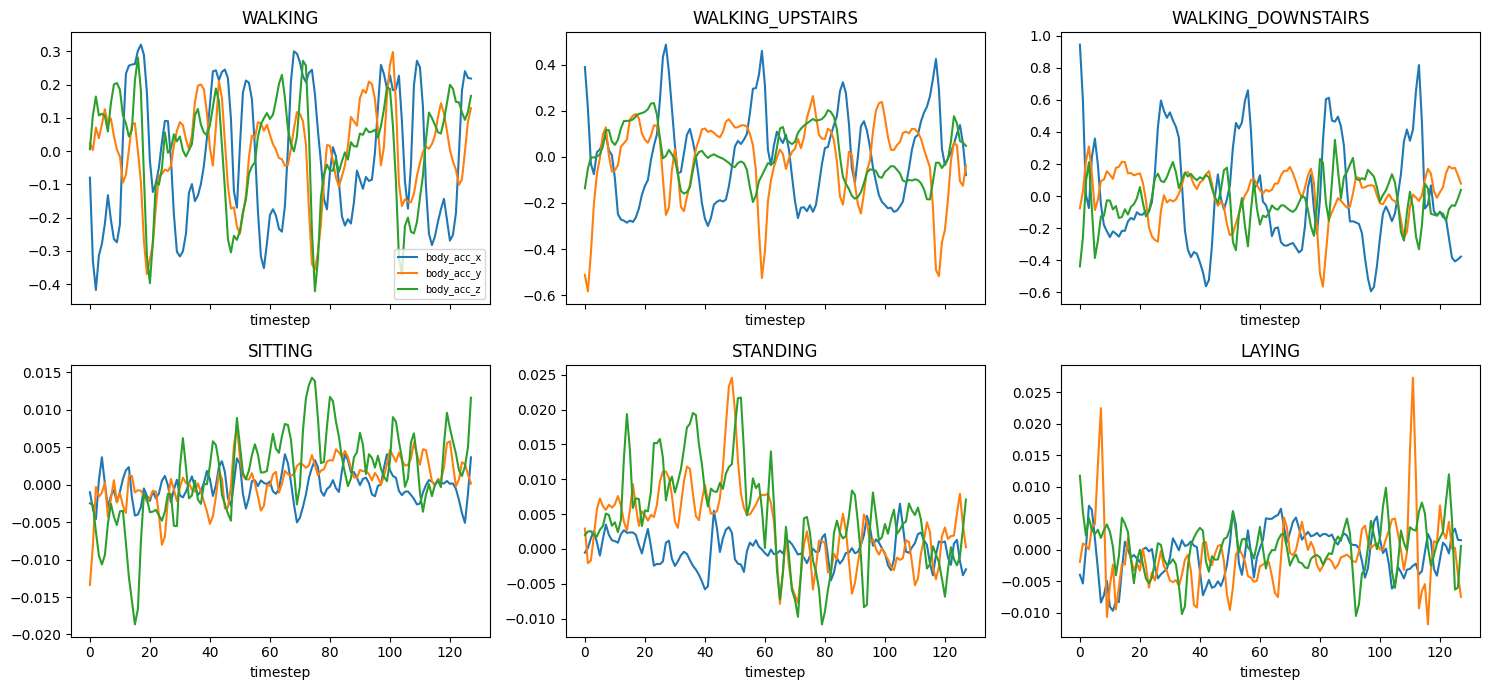

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharex=True)
for i, act in enumerate(ACTIVITIES):
    ax = axes[i // 3, i % 3]
    idx = np.where(data["y_train"] == i)[0]
    sample = data["X_train_raw"][idx[0]]
    for c in range(3):
        ax.plot(sample[:, c], label=CHANNELS[c])
    ax.set_title(act); ax.set_xlabel("timestep")
    if i == 0: ax.legend(fontsize=7)
plt.tight_layout()
temporal_fig_path = FIG_DIR / "temporal_signals.png"
plt.savefig(temporal_fig_path, dpi=150); plt.show()
SUMMARY["temporal_visualization_figure"] = str(temporal_fig_path)

In [21]:
x = [0.5, 0.7, 0.2]; h0 = 0.0; Wx, Wh, b = 0.5, 0.8, 0.1

h = h0; manual_h = []
for xt in x:
    h = np.tanh(Wx * xt + Wh * h + b)
    manual_h.append(h)

cell = layers.SimpleRNNCell(1, activation="tanh")
cell.build(input_shape=(1,))
cell.set_weights([np.array([[Wx]], dtype=np.float32),
                   np.array([[Wh]], dtype=np.float32),
                   np.array([b], dtype=np.float32)])
state = tf.zeros((1, 1)); prog_h = []
for xt in x:
    out, [state] = cell(tf.constant([[xt]], dtype=tf.float32), [state])
    prog_h.append(float(out.numpy()[0, 0]))

SUMMARY["numerical_rnn_exercise"] = {"manual_h": manual_h, "programmatic_h": prog_h}
print(SUMMARY["numerical_rnn_exercise"])

{'manual_h': [np.float64(0.3363755443363322), np.float64(0.6163517827505027), np.float64(0.5999579155496113)], 'programmatic_h': [0.33637553453445435, 0.6163517832756042, 0.5999579429626465]}


In [22]:
def build_rnn(input_shape, n_classes):
    return models.Sequential([
        layers.Input(shape=input_shape), layers.SimpleRNN(32), layers.Dropout(0.2),
        layers.Dense(16, activation="relu"), layers.Dense(n_classes, activation="softmax"),
    ], name="VanillaRNN")

def build_lstm(input_shape, n_classes, units=32):
    return models.Sequential([
        layers.Input(shape=input_shape), layers.LSTM(units), layers.Dropout(0.2),
        layers.Dense(16, activation="relu"), layers.Dense(n_classes, activation="softmax"),
    ], name="LSTM")

def build_gru(input_shape, n_classes, units=32):
    return models.Sequential([
        layers.Input(shape=input_shape), layers.GRU(units), layers.Dropout(0.2),
        layers.Dense(16, activation="relu"), layers.Dense(n_classes, activation="softmax"),
    ], name="GRU")

In [23]:
def train_and_evaluate(name, model_fn, d, class_names, epochs=EPOCHS,
                        batch_size=BATCH_SIZE, tag_prefix=""):
    X_train, y_train = d["X_train"], d["y_train"]
    X_val, y_val = d["X_val"], d["y_val"]
    X_test, y_test = d["X_test"], d["y_test"]

    model = model_fn(X_train.shape[1:], len(class_names))
    model.compile(optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    n_params = model.count_params()

    es = callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True)
    t0 = time.time()
    history = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                         epochs=epochs, batch_size=batch_size, callbacks=[es], verbose=2)
    train_time = time.time() - t0

    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
    acc = accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="macro", zero_division=0)
    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=class_names, output_dict=True, zero_division=0)

    loss_path = FIG_DIR / f"{tag_prefix}{name}_loss.png"
    plt.figure(figsize=(6,4))
    plt.plot(history.history["loss"], label="train_loss"); plt.plot(history.history["val_loss"], label="val_loss")
    plt.title(f"{name} Training/Validation Loss"); plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend()
    plt.tight_layout(); plt.savefig(loss_path, dpi=150); plt.show()

    acc_path = FIG_DIR / f"{tag_prefix}{name}_accuracy.png"
    plt.figure(figsize=(6,4))
    plt.plot(history.history["accuracy"], label="train_acc"); plt.plot(history.history["val_accuracy"], label="val_acc")
    plt.title(f"{name} Training/Validation Accuracy"); plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.legend()
    plt.tight_layout(); plt.savefig(acc_path, dpi=150); plt.show()

    cm_path = FIG_DIR / f"{tag_prefix}{name}_confusion_matrix.png"
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.title(f"{name} Confusion Matrix"); plt.xlabel("Predicted"); plt.ylabel("True")
    plt.tight_layout(); plt.savefig(cm_path, dpi=150); plt.show()

    result = {
        "name": name, "parameters": int(n_params), "training_time_sec": round(train_time, 2),
        "epochs_run": len(history.history["loss"]),
        "test_accuracy": round(float(acc)*100, 2), "macro_precision": round(float(prec)*100, 2),
        "macro_recall": round(float(rec)*100, 2), "macro_f1": round(float(f1)*100, 2),
        "confusion_matrix": cm.tolist(), "classification_report": report,
        "figures": {"loss": str(loss_path), "accuracy": str(acc_path), "confusion_matrix": str(cm_path)},
        "history": {k: [round(float(v),5) for v in vals] for k, vals in history.history.items()},
    }
    print(f"{name}: acc={result['test_accuracy']}% f1={result['macro_f1']}% params={n_params} time={train_time:.1f}s")
    return result, model

Epoch 1/30
196/196 - 7s - 38ms/step - accuracy: 0.5315 - loss: 1.1818 - val_accuracy: 0.6298 - val_loss: 0.8732
Epoch 2/30
196/196 - 2s - 10ms/step - accuracy: 0.6157 - loss: 0.8857 - val_accuracy: 0.6951 - val_loss: 0.7083
Epoch 3/30
196/196 - 2s - 10ms/step - accuracy: 0.6765 - loss: 0.7168 - val_accuracy: 0.7314 - val_loss: 0.6188
Epoch 4/30
196/196 - 2s - 11ms/step - accuracy: 0.7058 - loss: 0.6363 - val_accuracy: 0.7387 - val_loss: 0.5773
Epoch 5/30
196/196 - 2s - 10ms/step - accuracy: 0.7318 - loss: 0.5911 - val_accuracy: 0.7523 - val_loss: 0.5561
Epoch 6/30
196/196 - 2s - 10ms/step - accuracy: 0.7486 - loss: 0.5653 - val_accuracy: 0.7604 - val_loss: 0.5329
Epoch 7/30
196/196 - 3s - 13ms/step - accuracy: 0.7546 - loss: 0.5486 - val_accuracy: 0.7677 - val_loss: 0.5321
Epoch 8/30
196/196 - 2s - 10ms/step - accuracy: 0.7701 - loss: 0.5251 - val_accuracy: 0.7786 - val_loss: 0.5040
Epoch 9/30
196/196 - 2s - 10ms/step - accuracy: 0.7866 - loss: 0.5054 - val_accuracy: 0.7967 - val_loss:

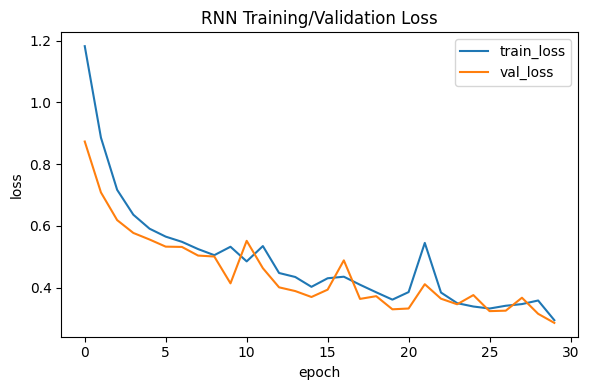

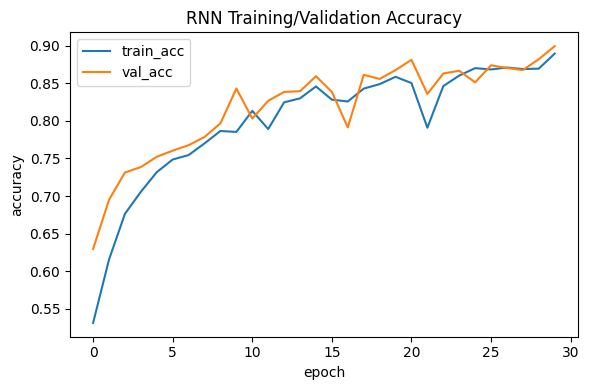

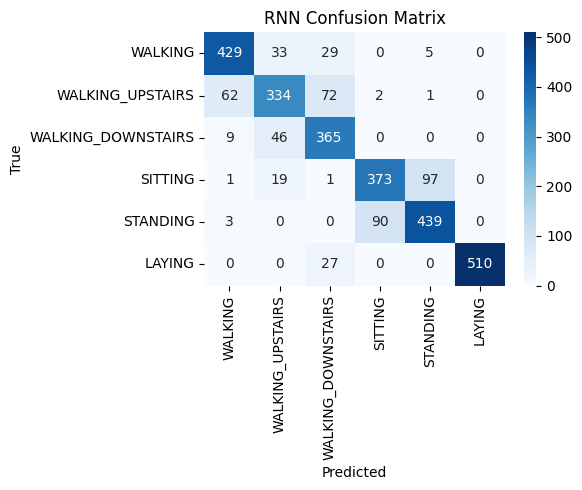

RNN: acc=83.14% f1=82.81% params=1974 time=65.7s
Epoch 1/30
196/196 - 3s - 16ms/step - accuracy: 0.5797 - loss: 1.1222 - val_accuracy: 0.7096 - val_loss: 0.6592
Epoch 2/30
196/196 - 2s - 9ms/step - accuracy: 0.7618 - loss: 0.5617 - val_accuracy: 0.8521 - val_loss: 0.4055
Epoch 3/30
196/196 - 2s - 13ms/step - accuracy: 0.8813 - loss: 0.3445 - val_accuracy: 0.9319 - val_loss: 0.2285
Epoch 4/30
196/196 - 2s - 9ms/step - accuracy: 0.9189 - loss: 0.2287 - val_accuracy: 0.9428 - val_loss: 0.1844
Epoch 5/30
196/196 - 2s - 9ms/step - accuracy: 0.9336 - loss: 0.1965 - val_accuracy: 0.9474 - val_loss: 0.1400
Epoch 6/30
196/196 - 2s - 9ms/step - accuracy: 0.9446 - loss: 0.1558 - val_accuracy: 0.9528 - val_loss: 0.1403
Epoch 7/30
196/196 - 2s - 9ms/step - accuracy: 0.9360 - loss: 0.1689 - val_accuracy: 0.9510 - val_loss: 0.1300
Epoch 8/30
196/196 - 2s - 9ms/step - accuracy: 0.9398 - loss: 0.1530 - val_accuracy: 0.9519 - val_loss: 0.1202
Epoch 9/30
196/196 - 2s - 11ms/step - accuracy: 0.9477 - loss

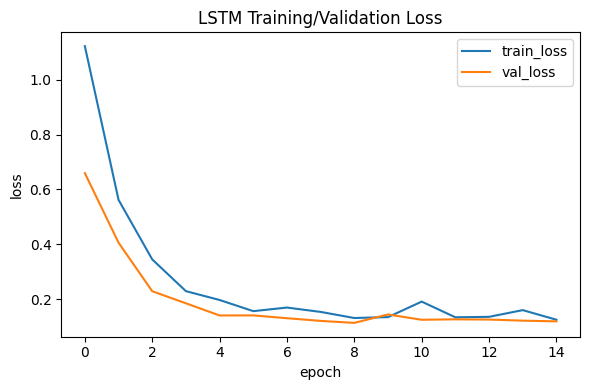

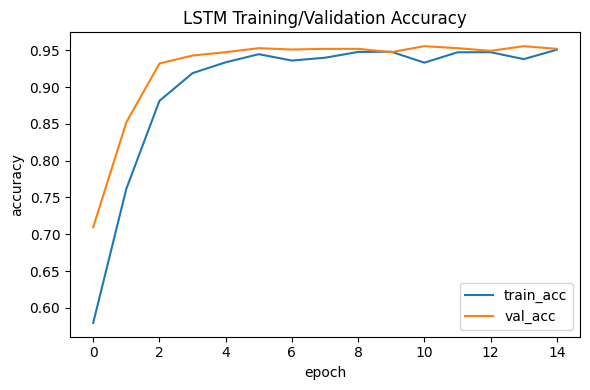

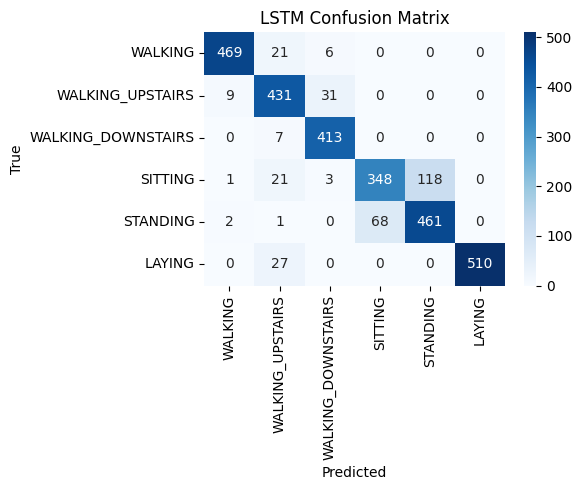

LSTM: acc=89.31% f1=89.3% params=6006 time=30.0s
Epoch 1/30
196/196 - 3s - 15ms/step - accuracy: 0.5565 - loss: 1.2021 - val_accuracy: 0.7069 - val_loss: 0.6676
Epoch 2/30
196/196 - 2s - 9ms/step - accuracy: 0.7749 - loss: 0.5535 - val_accuracy: 0.8593 - val_loss: 0.4218
Epoch 3/30
196/196 - 2s - 9ms/step - accuracy: 0.9030 - loss: 0.3025 - val_accuracy: 0.9510 - val_loss: 0.1636
Epoch 4/30
196/196 - 2s - 9ms/step - accuracy: 0.9430 - loss: 0.1649 - val_accuracy: 0.9583 - val_loss: 0.1243
Epoch 5/30
196/196 - 2s - 10ms/step - accuracy: 0.9435 - loss: 0.1541 - val_accuracy: 0.9583 - val_loss: 0.1150
Epoch 6/30
196/196 - 2s - 12ms/step - accuracy: 0.9466 - loss: 0.1341 - val_accuracy: 0.9583 - val_loss: 0.1168
Epoch 7/30
196/196 - 2s - 9ms/step - accuracy: 0.9480 - loss: 0.1256 - val_accuracy: 0.9564 - val_loss: 0.1100
Epoch 8/30
196/196 - 2s - 9ms/step - accuracy: 0.9485 - loss: 0.1245 - val_accuracy: 0.9574 - val_loss: 0.1073
Epoch 9/30
196/196 - 2s - 9ms/step - accuracy: 0.9514 - loss

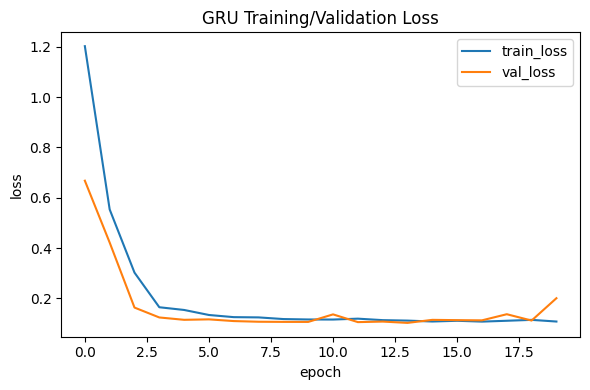

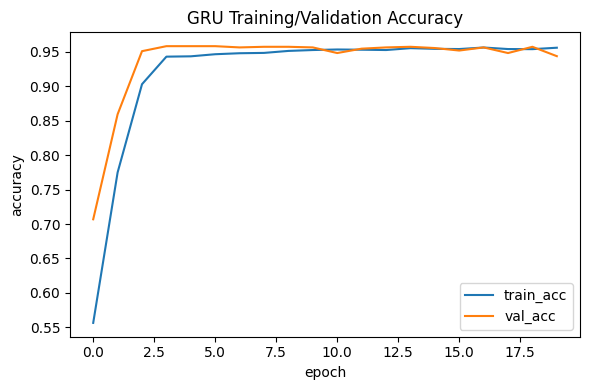

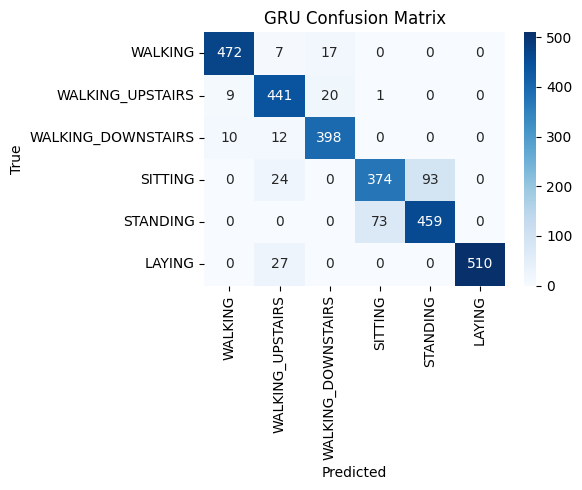

GRU: acc=90.06% f1=90.05% params=4758 time=39.0s


In [24]:
model_results = {}
for name, fn in [("RNN", build_rnn), ("LSTM", build_lstm), ("GRU", build_gru)]:
    res, _ = train_and_evaluate(name, fn, data, ACTIVITIES)
    model_results[name] = res
SUMMARY["rnn_lstm_gru_comparison"] = model_results

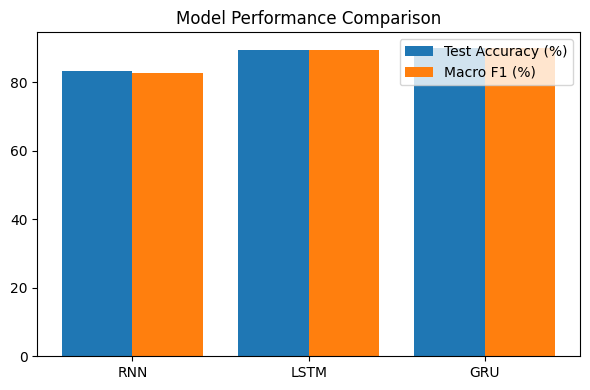

In [25]:
names = list(model_results.keys())
accs = [model_results[n]["test_accuracy"] for n in names]
f1s = [model_results[n]["macro_f1"] for n in names]
x = np.arange(len(names))
plt.figure(figsize=(6,4))
plt.bar(x-0.2, accs, width=0.4, label="Test Accuracy (%)")
plt.bar(x+0.2, f1s, width=0.4, label="Macro F1 (%)")
plt.xticks(x, names); plt.title("Model Performance Comparison"); plt.legend()
plt.tight_layout()
perf_path = FIG_DIR / "model_performance_comparison.png"
plt.savefig(perf_path, dpi=150); plt.show()
SUMMARY["model_performance_figure"] = str(perf_path)

Epoch 1/15
196/196 - 6s - 28ms/step - accuracy: 0.5464 - loss: 1.1689 - val_accuracy: 0.6751 - val_loss: 0.7809
Epoch 2/15
196/196 - 2s - 8ms/step - accuracy: 0.6715 - loss: 0.7289 - val_accuracy: 0.7205 - val_loss: 0.6473
Epoch 3/15
196/196 - 1s - 7ms/step - accuracy: 0.7061 - loss: 0.6404 - val_accuracy: 0.7350 - val_loss: 0.5912
Epoch 4/15
196/196 - 1s - 5ms/step - accuracy: 0.7282 - loss: 0.6038 - val_accuracy: 0.7695 - val_loss: 0.5762
Epoch 5/15
196/196 - 1s - 5ms/step - accuracy: 0.7317 - loss: 0.6084 - val_accuracy: 0.7704 - val_loss: 0.5503
Epoch 6/15
196/196 - 1s - 5ms/step - accuracy: 0.7574 - loss: 0.5580 - val_accuracy: 0.7967 - val_loss: 0.5250
Epoch 7/15
196/196 - 1s - 5ms/step - accuracy: 0.7749 - loss: 0.5280 - val_accuracy: 0.8221 - val_loss: 0.4806
Epoch 8/15
196/196 - 1s - 5ms/step - accuracy: 0.7832 - loss: 0.5099 - val_accuracy: 0.8176 - val_loss: 0.4813
Epoch 9/15
196/196 - 1s - 6ms/step - accuracy: 0.7910 - loss: 0.5155 - val_accuracy: 0.8212 - val_loss: 0.4516


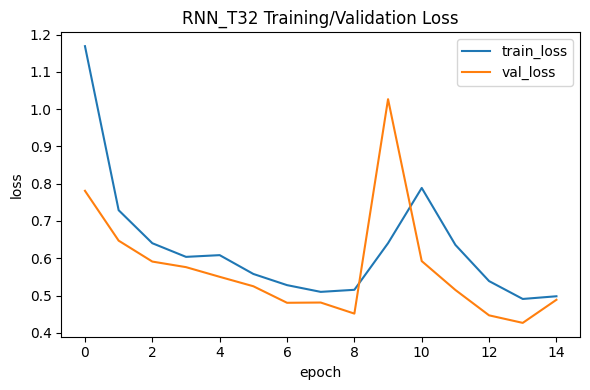

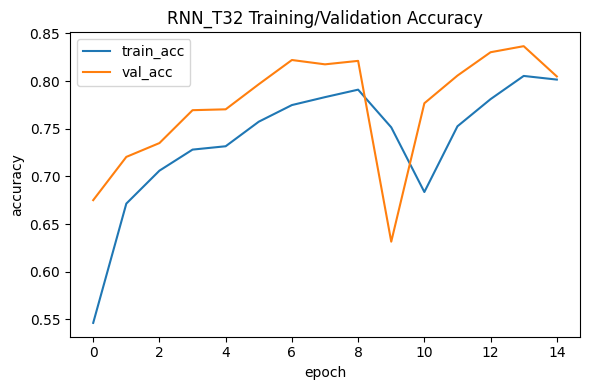

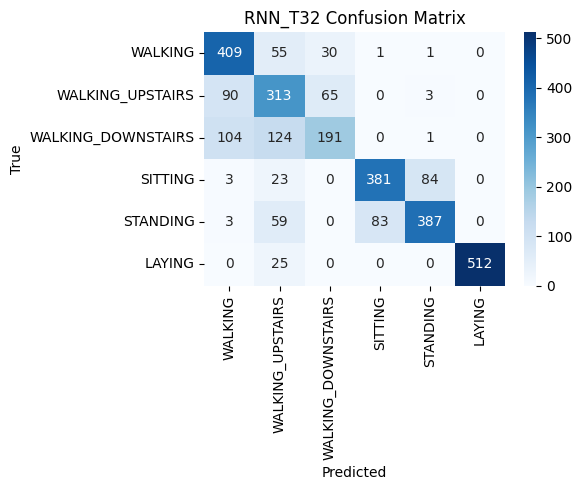

RNN_T32: acc=74.41% f1=73.46% params=1974 time=21.9s
Epoch 1/15
196/196 - 3s - 13ms/step - accuracy: 0.6251 - loss: 1.0824 - val_accuracy: 0.8185 - val_loss: 0.5027
Epoch 2/15
196/196 - 1s - 7ms/step - accuracy: 0.8549 - loss: 0.4051 - val_accuracy: 0.8975 - val_loss: 0.2766
Epoch 3/15
196/196 - 1s - 7ms/step - accuracy: 0.9162 - loss: 0.2411 - val_accuracy: 0.9102 - val_loss: 0.2198
Epoch 4/15
196/196 - 1s - 7ms/step - accuracy: 0.9267 - loss: 0.1997 - val_accuracy: 0.9265 - val_loss: 0.1918
Epoch 5/15
196/196 - 2s - 12ms/step - accuracy: 0.9334 - loss: 0.1835 - val_accuracy: 0.9446 - val_loss: 0.1589
Epoch 6/15
196/196 - 1s - 7ms/step - accuracy: 0.9389 - loss: 0.1578 - val_accuracy: 0.9437 - val_loss: 0.1589
Epoch 7/15
196/196 - 1s - 7ms/step - accuracy: 0.9408 - loss: 0.1483 - val_accuracy: 0.9446 - val_loss: 0.1566
Epoch 8/15
196/196 - 3s - 13ms/step - accuracy: 0.9466 - loss: 0.1360 - val_accuracy: 0.9465 - val_loss: 0.1466
Epoch 9/15
196/196 - 1s - 7ms/step - accuracy: 0.9394 - 

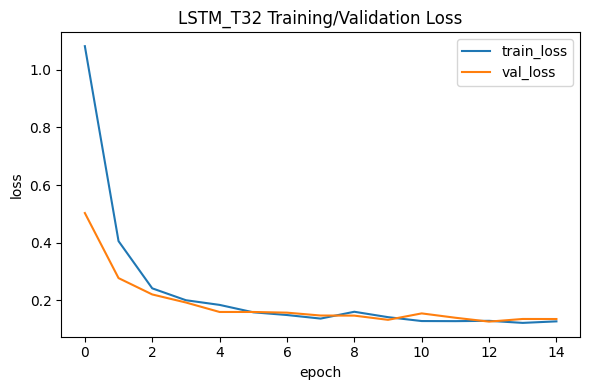

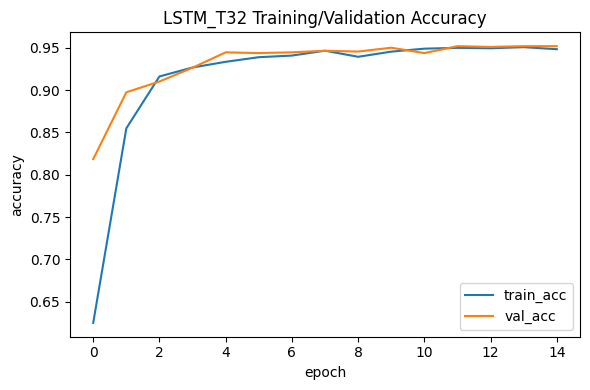

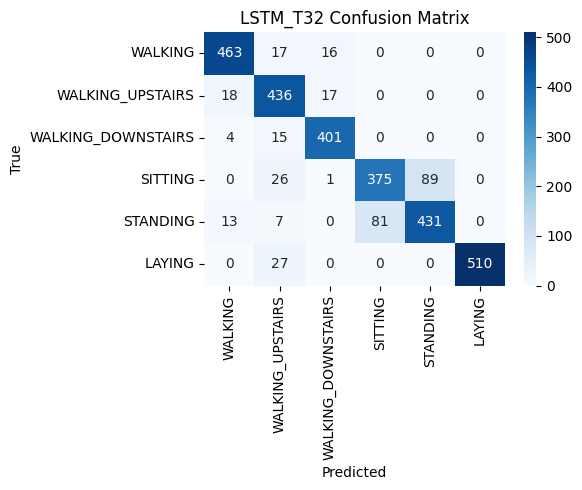

LSTM_T32: acc=88.77% f1=88.8% params=6006 time=25.6s
Epoch 1/15
196/196 - 3s - 13ms/step - accuracy: 0.4931 - loss: 1.2438 - val_accuracy: 0.7060 - val_loss: 0.8252
Epoch 2/15
196/196 - 2s - 8ms/step - accuracy: 0.7546 - loss: 0.6128 - val_accuracy: 0.8766 - val_loss: 0.3964
Epoch 3/15
196/196 - 2s - 11ms/step - accuracy: 0.8893 - loss: 0.3172 - val_accuracy: 0.9256 - val_loss: 0.2075
Epoch 4/15
196/196 - 1s - 7ms/step - accuracy: 0.9184 - loss: 0.2154 - val_accuracy: 0.9256 - val_loss: 0.1801
Epoch 5/15
196/196 - 1s - 7ms/step - accuracy: 0.9282 - loss: 0.1879 - val_accuracy: 0.9401 - val_loss: 0.1519
Epoch 6/15
196/196 - 1s - 7ms/step - accuracy: 0.9347 - loss: 0.1631 - val_accuracy: 0.9401 - val_loss: 0.1407
Epoch 7/15
196/196 - 1s - 7ms/step - accuracy: 0.9392 - loss: 0.1542 - val_accuracy: 0.9374 - val_loss: 0.1395
Epoch 8/15
196/196 - 1s - 7ms/step - accuracy: 0.9443 - loss: 0.1417 - val_accuracy: 0.9428 - val_loss: 0.1341
Epoch 9/15
196/196 - 1s - 7ms/step - accuracy: 0.9419 - l

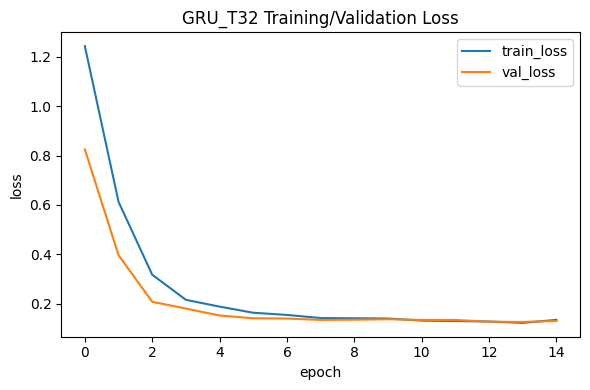

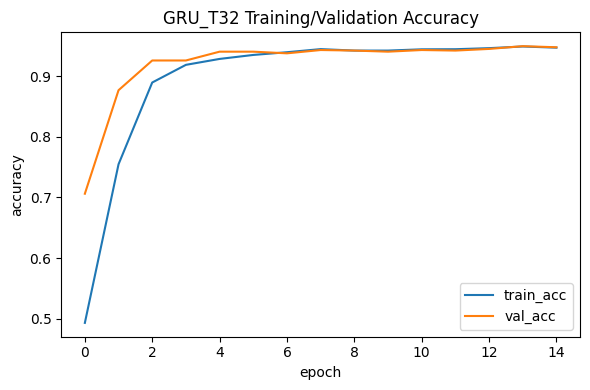

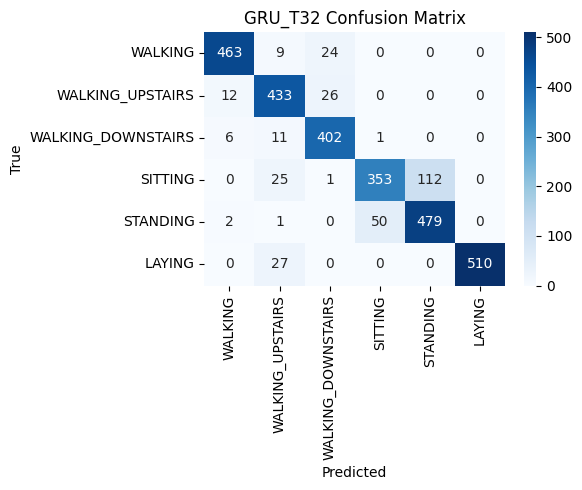

GRU_T32: acc=89.58% f1=89.49% params=4758 time=23.1s
Epoch 1/15
196/196 - 6s - 32ms/step - accuracy: 0.5434 - loss: 1.1696 - val_accuracy: 0.6733 - val_loss: 0.8042
Epoch 2/15
196/196 - 1s - 7ms/step - accuracy: 0.6882 - loss: 0.7402 - val_accuracy: 0.7341 - val_loss: 0.6643
Epoch 3/15
196/196 - 1s - 6ms/step - accuracy: 0.7349 - loss: 0.6496 - val_accuracy: 0.7441 - val_loss: 0.6206
Epoch 4/15
196/196 - 1s - 7ms/step - accuracy: 0.7136 - loss: 0.7242 - val_accuracy: 0.7414 - val_loss: 0.5950
Epoch 5/15
196/196 - 1s - 6ms/step - accuracy: 0.7485 - loss: 0.5988 - val_accuracy: 0.7759 - val_loss: 0.5460
Epoch 6/15
196/196 - 1s - 6ms/step - accuracy: 0.7598 - loss: 0.5578 - val_accuracy: 0.7868 - val_loss: 0.5204
Epoch 7/15
196/196 - 1s - 6ms/step - accuracy: 0.7797 - loss: 0.5248 - val_accuracy: 0.8022 - val_loss: 0.4885
Epoch 8/15
196/196 - 1s - 7ms/step - accuracy: 0.8027 - loss: 0.5036 - val_accuracy: 0.8058 - val_loss: 0.4638
Epoch 9/15
196/196 - 2s - 9ms/step - accuracy: 0.8147 - lo

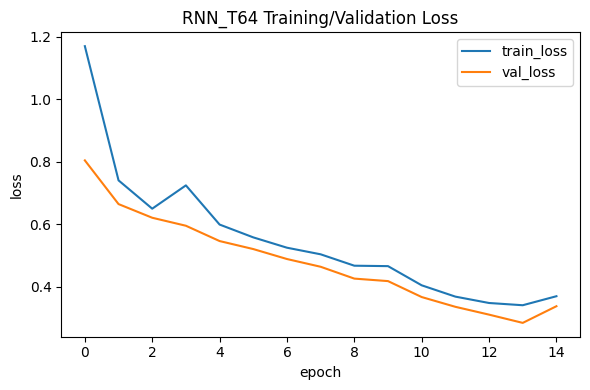

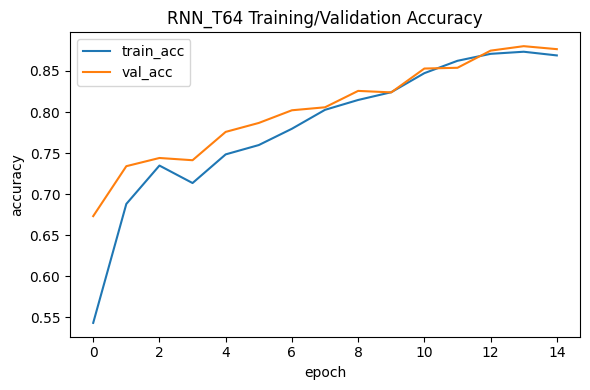

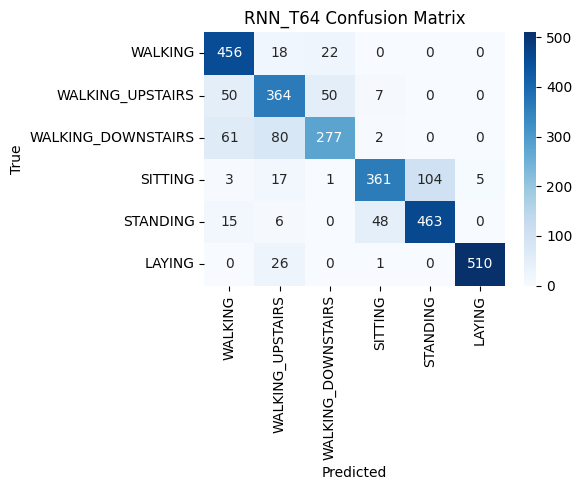

RNN_T64: acc=82.49% f1=81.83% params=1974 time=26.1s
Epoch 1/15
196/196 - 3s - 16ms/step - accuracy: 0.6077 - loss: 1.0517 - val_accuracy: 0.7486 - val_loss: 0.6301
Epoch 2/15
196/196 - 1s - 8ms/step - accuracy: 0.8006 - loss: 0.5253 - val_accuracy: 0.8049 - val_loss: 0.7393
Epoch 3/15
196/196 - 3s - 13ms/step - accuracy: 0.8859 - loss: 0.3505 - val_accuracy: 0.9319 - val_loss: 0.2192
Epoch 4/15
196/196 - 1s - 7ms/step - accuracy: 0.9194 - loss: 0.2319 - val_accuracy: 0.9265 - val_loss: 0.1852
Epoch 5/15
196/196 - 1s - 8ms/step - accuracy: 0.9136 - loss: 0.2595 - val_accuracy: 0.8621 - val_loss: 0.3717
Epoch 6/15
196/196 - 2s - 9ms/step - accuracy: 0.9014 - loss: 0.2633 - val_accuracy: 0.9365 - val_loss: 0.1690
Epoch 7/15
196/196 - 2s - 10ms/step - accuracy: 0.9318 - loss: 0.1826 - val_accuracy: 0.9410 - val_loss: 0.1407
Epoch 8/15
196/196 - 2s - 8ms/step - accuracy: 0.9346 - loss: 0.1642 - val_accuracy: 0.9456 - val_loss: 0.1413
Epoch 9/15
196/196 - 1s - 7ms/step - accuracy: 0.9410 - 

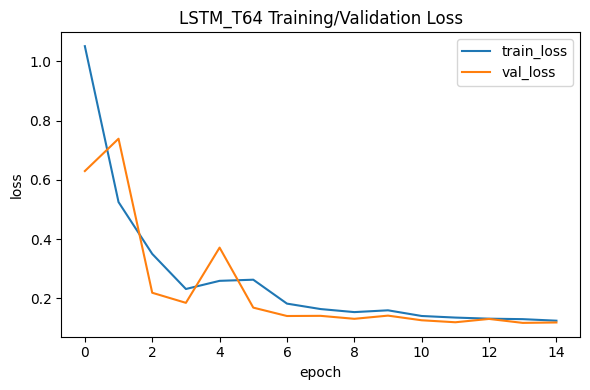

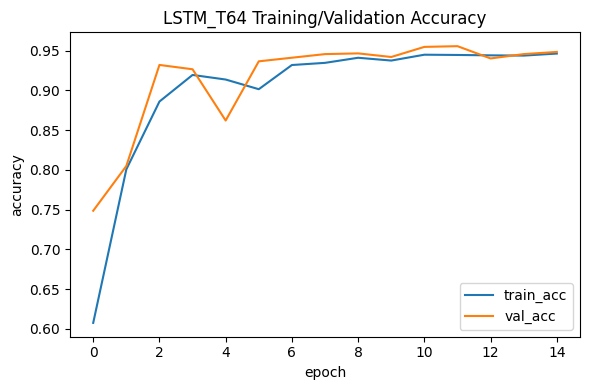

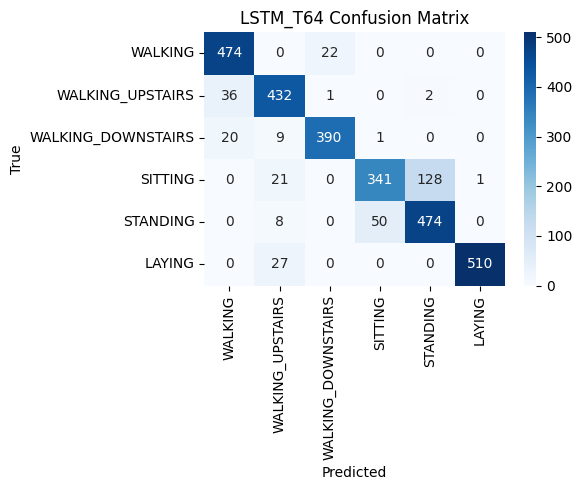

LSTM_T64: acc=88.94% f1=88.88% params=6006 time=28.0s
Epoch 1/15
196/196 - 3s - 14ms/step - accuracy: 0.4818 - loss: 1.3362 - val_accuracy: 0.6788 - val_loss: 0.9592
Epoch 2/15
196/196 - 1s - 7ms/step - accuracy: 0.7442 - loss: 0.7354 - val_accuracy: 0.8439 - val_loss: 0.4768
Epoch 3/15
196/196 - 3s - 14ms/step - accuracy: 0.8854 - loss: 0.3683 - val_accuracy: 0.9292 - val_loss: 0.2156
Epoch 4/15
196/196 - 2s - 10ms/step - accuracy: 0.9301 - loss: 0.2106 - val_accuracy: 0.9428 - val_loss: 0.1453
Epoch 5/15
196/196 - 1s - 7ms/step - accuracy: 0.9398 - loss: 0.1637 - val_accuracy: 0.9519 - val_loss: 0.1234
Epoch 6/15
196/196 - 1s - 7ms/step - accuracy: 0.9403 - loss: 0.1505 - val_accuracy: 0.9456 - val_loss: 0.1175
Epoch 7/15
196/196 - 1s - 7ms/step - accuracy: 0.9475 - loss: 0.1338 - val_accuracy: 0.9483 - val_loss: 0.1134
Epoch 8/15
196/196 - 1s - 7ms/step - accuracy: 0.9470 - loss: 0.1314 - val_accuracy: 0.9474 - val_loss: 0.1133
Epoch 9/15
196/196 - 1s - 7ms/step - accuracy: 0.9464 -

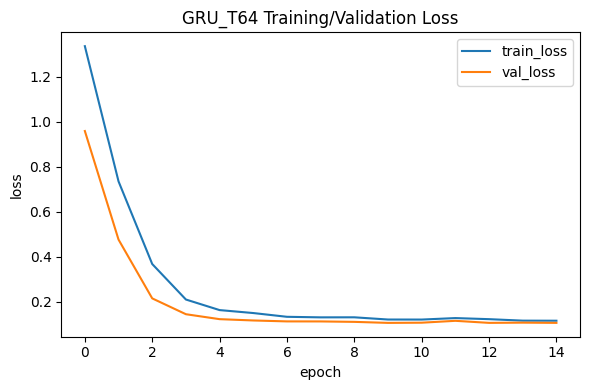

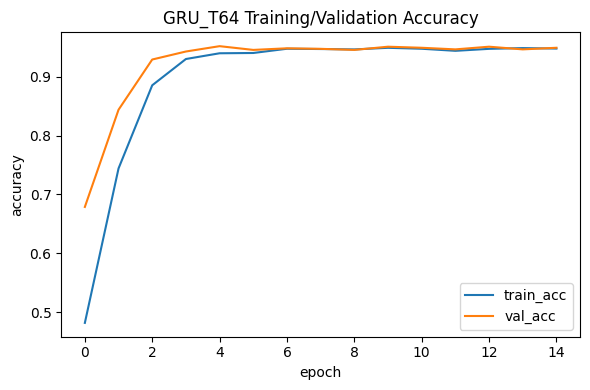

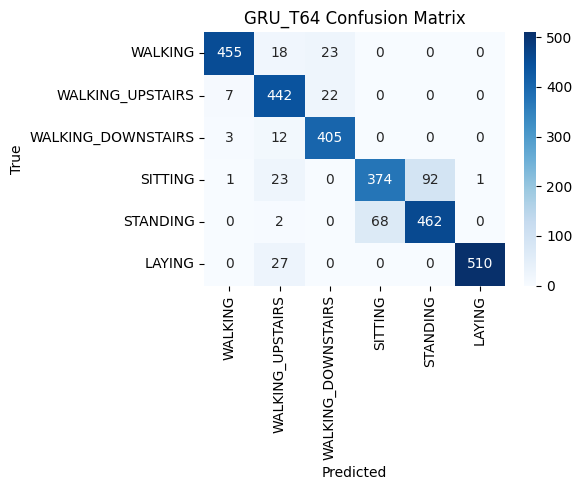

GRU_T64: acc=89.85% f1=89.85% params=4758 time=25.8s
Epoch 1/15
196/196 - 7s - 36ms/step - accuracy: 0.5123 - loss: 1.1727 - val_accuracy: 0.6488 - val_loss: 0.8682
Epoch 2/15
196/196 - 2s - 10ms/step - accuracy: 0.6541 - loss: 0.7734 - val_accuracy: 0.6987 - val_loss: 0.6504
Epoch 3/15
196/196 - 2s - 10ms/step - accuracy: 0.6965 - loss: 0.6538 - val_accuracy: 0.7123 - val_loss: 0.6201
Epoch 4/15
196/196 - 2s - 10ms/step - accuracy: 0.7157 - loss: 0.6088 - val_accuracy: 0.7532 - val_loss: 0.5659
Epoch 5/15
196/196 - 2s - 10ms/step - accuracy: 0.7243 - loss: 0.6531 - val_accuracy: 0.6497 - val_loss: 0.8470
Epoch 6/15
196/196 - 2s - 10ms/step - accuracy: 0.6770 - loss: 0.7340 - val_accuracy: 0.7205 - val_loss: 0.6402
Epoch 7/15
196/196 - 2s - 10ms/step - accuracy: 0.7181 - loss: 0.6189 - val_accuracy: 0.7486 - val_loss: 0.5603
Epoch 8/15
196/196 - 2s - 10ms/step - accuracy: 0.7438 - loss: 0.5670 - val_accuracy: 0.7450 - val_loss: 0.5272
Epoch 9/15
196/196 - 2s - 10ms/step - accuracy: 0.7

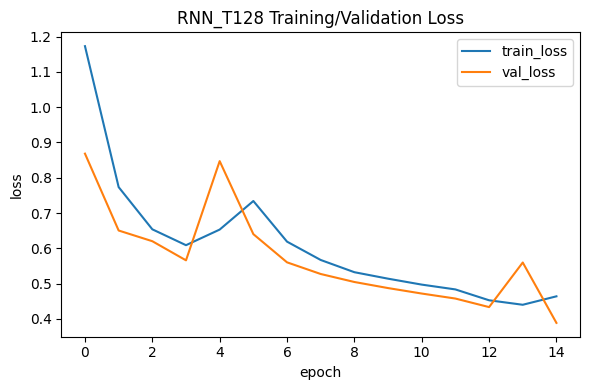

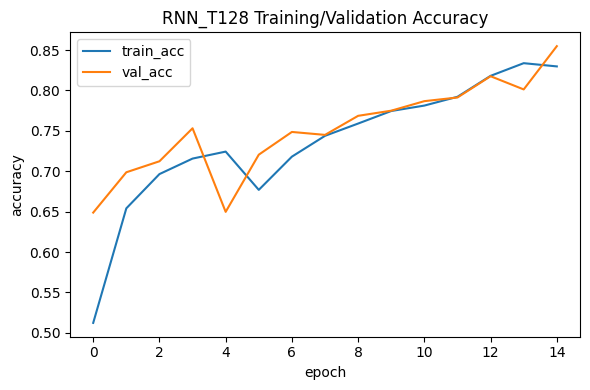

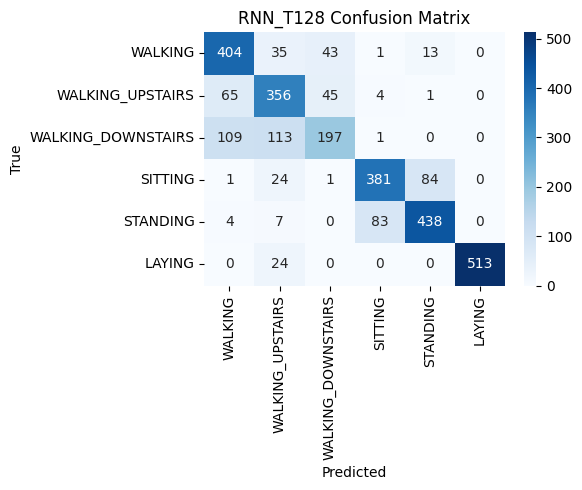

RNN_T128: acc=77.67% f1=76.47% params=1974 time=34.5s
Epoch 1/15
196/196 - 3s - 16ms/step - accuracy: 0.5554 - loss: 1.0632 - val_accuracy: 0.7368 - val_loss: 0.6701
Epoch 2/15
196/196 - 2s - 12ms/step - accuracy: 0.7726 - loss: 0.5787 - val_accuracy: 0.8040 - val_loss: 0.7320
Epoch 3/15
196/196 - 2s - 10ms/step - accuracy: 0.8835 - loss: 0.3564 - val_accuracy: 0.9147 - val_loss: 0.2546
Epoch 4/15
196/196 - 2s - 9ms/step - accuracy: 0.9282 - loss: 0.2161 - val_accuracy: 0.9501 - val_loss: 0.1432
Epoch 5/15
196/196 - 2s - 9ms/step - accuracy: 0.9328 - loss: 0.1932 - val_accuracy: 0.9401 - val_loss: 0.1556
Epoch 6/15
196/196 - 2s - 10ms/step - accuracy: 0.9374 - loss: 0.1680 - val_accuracy: 0.9510 - val_loss: 0.1250
Epoch 7/15
196/196 - 2s - 10ms/step - accuracy: 0.9411 - loss: 0.1515 - val_accuracy: 0.9465 - val_loss: 0.1287
Epoch 8/15
196/196 - 2s - 12ms/step - accuracy: 0.9438 - loss: 0.1448 - val_accuracy: 0.9301 - val_loss: 0.2267
Epoch 9/15
196/196 - 2s - 11ms/step - accuracy: 0.94

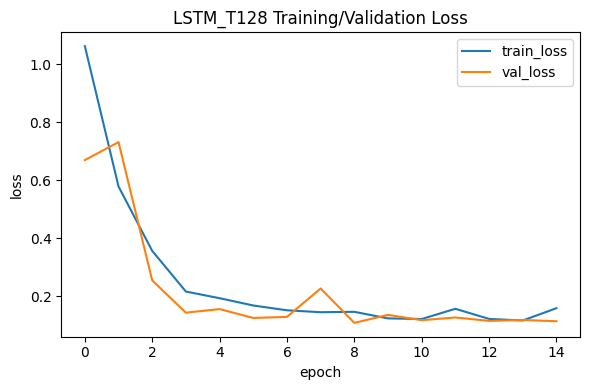

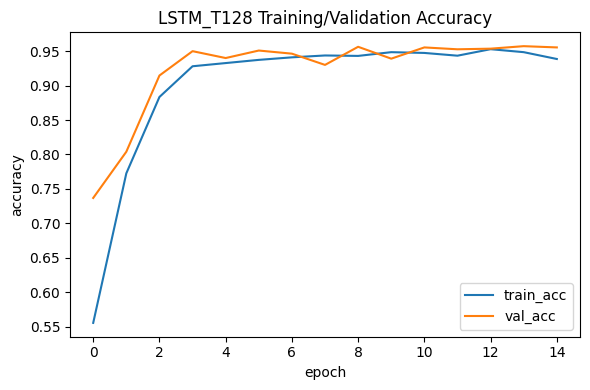

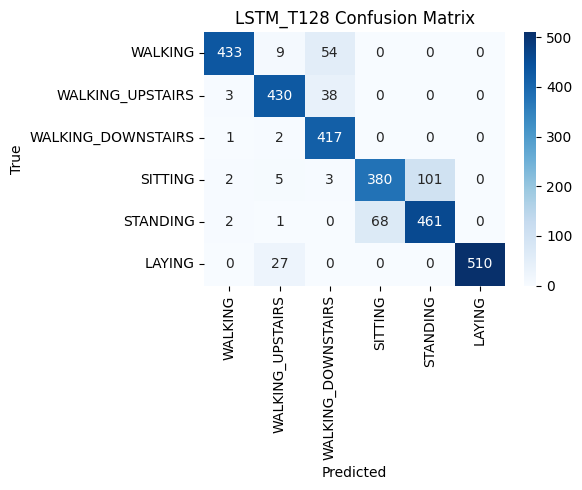

LSTM_T128: acc=89.28% f1=89.26% params=6006 time=31.7s
Epoch 1/15
196/196 - 4s - 20ms/step - accuracy: 0.5187 - loss: 1.2152 - val_accuracy: 0.7033 - val_loss: 0.6668
Epoch 2/15
196/196 - 2s - 12ms/step - accuracy: 0.7675 - loss: 0.5492 - val_accuracy: 0.8802 - val_loss: 0.3500
Epoch 3/15
196/196 - 2s - 12ms/step - accuracy: 0.8902 - loss: 0.3037 - val_accuracy: 0.9356 - val_loss: 0.2167
Epoch 4/15
196/196 - 2s - 11ms/step - accuracy: 0.9334 - loss: 0.1965 - val_accuracy: 0.9501 - val_loss: 0.1564
Epoch 5/15
196/196 - 2s - 9ms/step - accuracy: 0.9434 - loss: 0.1619 - val_accuracy: 0.9555 - val_loss: 0.1273
Epoch 6/15
196/196 - 2s - 10ms/step - accuracy: 0.9477 - loss: 0.1444 - val_accuracy: 0.9583 - val_loss: 0.1167
Epoch 7/15
196/196 - 2s - 10ms/step - accuracy: 0.9493 - loss: 0.1313 - val_accuracy: 0.9601 - val_loss: 0.1104
Epoch 8/15
196/196 - 2s - 9ms/step - accuracy: 0.9507 - loss: 0.1284 - val_accuracy: 0.9583 - val_loss: 0.1114
Epoch 9/15
196/196 - 2s - 11ms/step - accuracy: 0.9

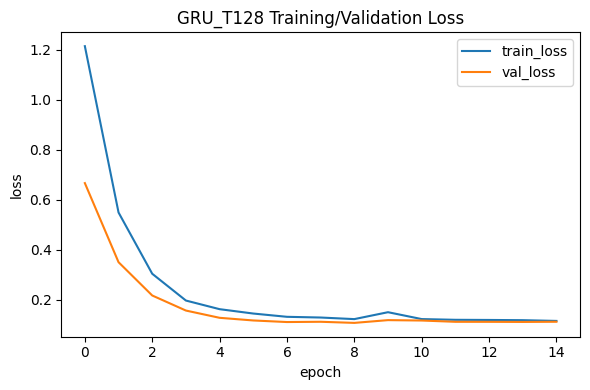

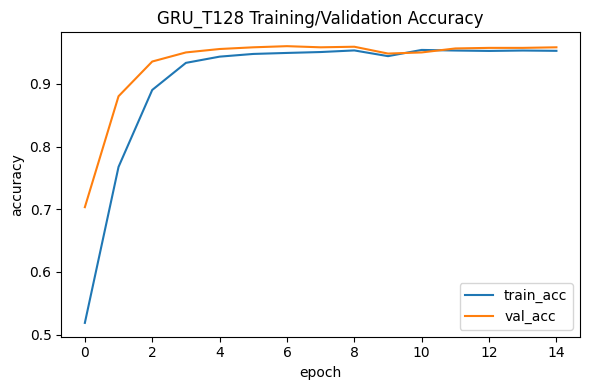

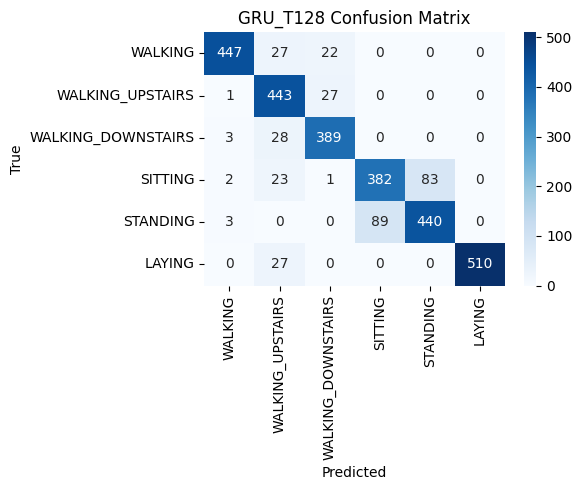

GRU_T128: acc=88.6% f1=88.61% params=4758 time=33.3s


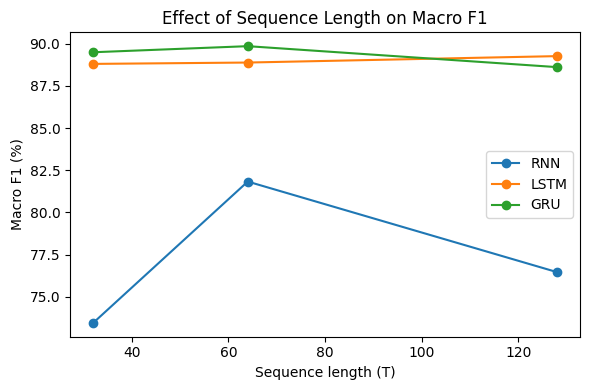

In [26]:
seqlen_results = {}
for T in [32, 64, 128]:
    sub = {"X_train": data["X_train"][:, -T:, :], "y_train": data["y_train"],
           "X_val": data["X_val"][:, -T:, :], "y_val": data["y_val"],
           "X_test": data["X_test"][:, -T:, :], "y_test": data["y_test"]}
    row = {}
    for name, fn in [("RNN", build_rnn), ("LSTM", build_lstm), ("GRU", build_gru)]:
        res, _ = train_and_evaluate(f"{name}_T{T}", fn, sub, ACTIVITIES, epochs=15, tag_prefix="seqlen_")
        row[name] = res["macro_f1"]
    seqlen_results[str(T)] = row

plt.figure(figsize=(6,4))
Ts = [32, 64, 128]
for name in ["RNN", "LSTM", "GRU"]:
    plt.plot(Ts, [seqlen_results[str(t)][name] for t in Ts], marker="o", label=name)
plt.xlabel("Sequence length (T)"); plt.ylabel("Macro F1 (%)")
plt.title("Effect of Sequence Length on Macro F1"); plt.legend()
plt.tight_layout()
seqlen_fig_path = FIG_DIR / "sequence_length_f1.png"
plt.savefig(seqlen_fig_path, dpi=150); plt.show()
SUMMARY["sequence_length_study"] = {"results": seqlen_results, "figure": str(seqlen_fig_path)}

## Video Understanding — real UCF101 5-class subset
Downloads only the needed files from the official UCF101 mirror
(`storage.googleapis.com/thumos14_files/UCF101_videos.zip`) using `remotezip`,
so the full ~6.5 GB archive is never fetched. If this genuinely fails in your
Colab session (network policy, mirror downtime), the notebook clearly falls
back to a synthetic dataset and **labels it as synthetic, never as UCF101**.

In [27]:
UCF_CLASSES = ["ApplyEyeMakeup", "Basketball", "Biking", "BreastStroke", "CricketShot"]
UCF_LABEL_IDS = {"ApplyEyeMakeup": 0, "Basketball": 7, "Biking": 10,
                  "BreastStroke": 18, "CricketShot": 23}
VIDEO_DIR = DATA_DIR / "video"
N_FRAMES = 10
FRAME_SIZE = (224, 224)
VIDEOS_PER_CLASS = 12

def try_download_real_ucf101_hf(videos_per_class=VIDEOS_PER_CLASS, max_scan=3_000_000):
    """
    Streams flwrlabs/ucf101 (frame-level UCF101 mirror on Hugging Face) and
    assembles `videos_per_class` real clips for each of UCF_CLASSES, without
    downloading the full 46GB dataset. Returns (success, {class: [clip_frames]})
    where clip_frames is a list of clips, each a list of (frame_idx, PIL.Image)
    sorted by frame_idx.
    """
    try:
        from datasets import load_dataset
    except ImportError:
        print("`datasets` library not available.")
        return False, {}

    id_to_class = {v: k for k, v in UCF_LABEL_IDS.items()}
    target_ids = set(UCF_LABEL_IDS.values())

    try:
        ds = load_dataset("flwrlabs/ucf101", split="train", streaming=True)
    except Exception as e:
        print(f"Could not open flwrlabs/ucf101 stream: {e}")
        return False, {}

    saved_clips = collections.defaultdict(list)
    counts_done = {c: 0 for c in UCF_LABEL_IDS}
    buf_clip_id, buf_frames, buf_label = None, [], None

    def flush_buffer():
        nonlocal buf_clip_id, buf_frames, buf_label
        if buf_clip_id is not None and buf_frames:
            cname = id_to_class[buf_label]
            if counts_done[cname] < videos_per_class:
                saved_clips[cname].append(sorted(buf_frames, key=lambda t: t[0]))
                counts_done[cname] += 1
        buf_clip_id, buf_frames, buf_label = None, [], None

    try:
        for i, ex in enumerate(ds):
            if i >= max_scan:
                print(f"Reached scan limit ({max_scan} rows) before collecting enough clips.")
                break
            if all(v >= videos_per_class for v in counts_done.values()):
                break
            if ex["label"] not in target_ids:
                continue
            cname = id_to_class[ex["label"]]
            if counts_done[cname] >= videos_per_class:
                continue
            cid = ex["clip_id"]
            if cid != buf_clip_id:
                flush_buffer()
                buf_clip_id, buf_label = cid, ex["label"]
            buf_frames.append((ex["frame"], ex["image"]))
            if i % 20000 == 0:
                print(f"  scanned {i} rows, collected so far: {counts_done}")
        flush_buffer()
    except Exception as e:
        print(f"Streaming failed midway ({e}); using whatever was collected so far.")

    print("Final counts:", counts_done)
    if not all(counts_done[c] > 0 for c in UCF_LABEL_IDS):
        print("Did not obtain real clips for every class.")
        return False, {}
    return True, saved_clips

def clips_to_arrays(saved_clips, n_frames=N_FRAMES, size=FRAME_SIZE):
    X, y = [], []
    for ci, cname in enumerate(UCF_CLASSES):
        for clip in saved_clips.get(cname, []):
            frame_imgs = [img for _, img in clip]
            total = len(frame_imgs)
            if total == 0:
                continue
            idxs = np.linspace(0, total - 1, n_frames).astype(int)
            frames = [np.array(frame_imgs[idx].convert("RGB").resize(size)) for idx in idxs]
            X.append(np.stack(frames))
            y.append(ci)
    return np.stack(X), np.array(y)


def ucf_class_of(filename):
    stem = pathlib.Path(filename).stem
    return stem.split("_")[1]

def try_download_real_ucf101_gcs():
    UCF_ZIP_URL = "https://storage.googleapis.com/thumos14_files/UCF101_videos.zip"
    try:
        with rz.RemoteZip(UCF_ZIP_URL) as zf:
            all_files = [f for f in zf.namelist() if f.endswith(".avi")]
            by_class = collections.defaultdict(list)
            for f in all_files:
                by_class[ucf_class_of(f)].append(f)
            missing = [c for c in UCF_CLASSES if not by_class.get(c)]
            if missing:
                raise RuntimeError(f"classes missing: {missing}")
            selected = {}
            for c in UCF_CLASSES:
                files_c = sorted(by_class[c])[:VIDEOS_PER_CLASS]
                class_dir = VIDEO_DIR / c
                class_dir.mkdir(parents=True, exist_ok=True)
                paths = []
                for fn in tqdm.tqdm(files_c, desc=f"gcs:{c}"):
                    zf.extract(fn, path=str(class_dir))
                    extracted = class_dir / fn
                    target = class_dir / pathlib.Path(fn).name
                    if extracted != target:
                        shutil.move(str(extracted), str(target))
                    paths.append(target)
                selected[c] = paths
            return True, selected
    except Exception as e:
        print(f"GCS remotezip failed: {e}")
        return False, {}

def frames_from_video_file(path, n_frames, size=FRAME_SIZE):
    cap = cv2.VideoCapture(str(path))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total <= 0:
        cap.release(); return None
    idxs = np.linspace(0, max(total - 1, 0), n_frames).astype(int)
    frames = []
    for target_idx in idxs:
        cap.set(cv2.CAP_PROP_POS_FRAMES, target_idx)
        ok, frame = cap.read()
        if not ok:
            cap.release(); return None
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame = cv2.resize(frame, size)
        frames.append(frame)
    cap.release()
    return np.stack(frames)

def load_real_ucf101_arrays_from_paths(selected):
    X, y = [], []
    for ci, c in enumerate(UCF_CLASSES):
        for path in selected[c]:
            clip = frames_from_video_file(path, N_FRAMES)
            if clip is not None:
                X.append(clip); y.append(ci)
    return np.stack(X), np.array(y)

def generate_synthetic_video_dataset(n_per_class=40, n_frames=N_FRAMES, size=64):
    rng = np.random.RandomState(SEED)
    X, y = [], []
    for ci, _ in enumerate(UCF_CLASSES):
        for _ in range(n_per_class):
            clip = np.zeros((n_frames, size, size, 3), dtype=np.uint8)
            cx, cy = rng.randint(10, size - 10, size=2)
            angle = (ci / len(UCF_CLASSES)) * 2 * np.pi + rng.uniform(-0.3, 0.3)
            speed = 2 + ci
            dx, dy = speed * np.cos(angle), speed * np.sin(angle)
            color = tuple(int(v) for v in rng.randint(80, 255, size=3))
            for f in range(n_frames):
                frame = np.zeros((size, size, 3), dtype=np.uint8)
                px = int(np.clip(cx + dx * f, 5, size - 5))
                py = int(np.clip(cy + dy * f, 5, size - 5))
                yy, xx = np.ogrid[:size, :size]
                mask = (xx - px) ** 2 + (yy - py) ** 2 <= 6 ** 2
                frame[mask] = color
                clip[f] = frame
            X.append(clip); y.append(ci)
    X = np.stack(X); y = np.array(y)
    idx = rng.permutation(len(X))
    return X[idx], y[idx]


# --- run the cascade: Hugging Face stream -> GCS mirror -> synthetic ---
used_real_ucf101 = False
X_video, y_video = None, None

print("Attempt 1: streaming real UCF101 frames from Hugging Face (flwrlabs/ucf101) ...")
ok, saved_clips = try_download_real_ucf101_hf()
if ok:
    X_video, y_video = clips_to_arrays(saved_clips)
    used_real_ucf101 = True

if not used_real_ucf101:
    print("Attempt 2: real UCF101 subset via GCS mirror ...")
    ok, selected = try_download_real_ucf101_gcs()
    if ok:
        X_video, y_video = load_real_ucf101_arrays_from_paths(selected)
        used_real_ucf101 = True

if not used_real_ucf101:
    print("Using SYNTHETIC fallback video dataset (clearly flagged, not UCF101).")
    X_video, y_video = generate_synthetic_video_dataset(n_per_class=40)

print("Video array shape:", X_video.shape, "| real UCF101 used:", used_real_ucf101)

Attempt 1: streaming real UCF101 frames from Hugging Face (flwrlabs/ucf101) ...


Resolving data files:   0%|          | 0/64 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/30 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/64 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/30 [00:00<?, ?it/s]

  scanned 0 rows, collected so far: {'ApplyEyeMakeup': 0, 'Basketball': 0, 'Biking': 0, 'BreastStroke': 0, 'CricketShot': 0}
Final counts: {'ApplyEyeMakeup': 12, 'Basketball': 12, 'Biking': 12, 'BreastStroke': 12, 'CricketShot': 12}
Video array shape: (60, 10, 224, 224, 3) | real UCF101 used: True


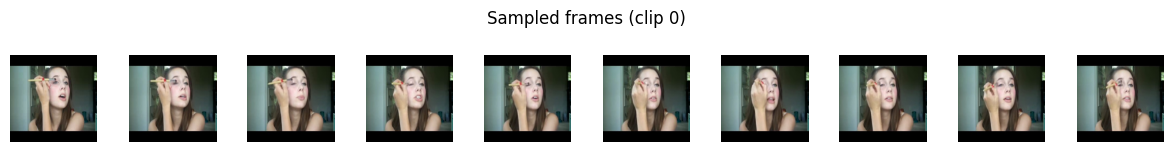

Extracting CNN features ...
Feature tensor shape (train): (42, 10, 1280)  (10 x D, D=1280)


In [28]:
n = len(X_video)
n_train = int(0.7 * n); n_val = int(0.15 * n)
X_train_v, y_train_v = X_video[:n_train], y_video[:n_train]
X_val_v, y_val_v = X_video[n_train:n_train+n_val], y_video[n_train:n_train+n_val]
X_test_v, y_test_v = X_video[n_train+n_val:], y_video[n_train+n_val:]

fig, axes = plt.subplots(1, N_FRAMES, figsize=(N_FRAMES*1.2, 1.5))
for i in range(N_FRAMES):
    axes[i].imshow(X_train_v[0, i]); axes[i].axis("off")
plt.suptitle("Sampled frames (clip 0)")
frame_fig_path = FIG_DIR / "video_sample_frames.png"
plt.tight_layout(); plt.savefig(frame_fig_path, dpi=150); plt.show()

def extract_cnn_features(frames_batch, cnn):
    B, T, H, W, C = frames_batch.shape
    flat = frames_batch.reshape(B*T, H, W, C).astype(np.float32)
    flat_resized = tf.image.resize(flat, FRAME_SIZE).numpy()
    flat_pre = tf.keras.applications.mobilenet_v2.preprocess_input(flat_resized)
    feats = cnn.predict(flat_pre, batch_size=64, verbose=0)
    D = feats.shape[-1]
    return feats.reshape(B, T, D)

base_cnn = tf.keras.applications.MobileNetV2(input_shape=(*FRAME_SIZE, 3),
                                              include_top=False, weights="imagenet", pooling="avg")
base_cnn.trainable = False

print("Extracting CNN features ...")
feat_train = extract_cnn_features(X_train_v, base_cnn)
feat_val = extract_cnn_features(X_val_v, base_cnn)
feat_test = extract_cnn_features(X_test_v, base_cnn)
D = feat_train.shape[-1]
print(f"Feature tensor shape (train): {feat_train.shape}  (10 x D, D={D})")

Epoch 1/20
3/3 - 1s - 464ms/step - accuracy: 0.2381 - loss: 1.6249 - val_accuracy: 0.0000e+00 - val_loss: 1.6371
Epoch 2/20
3/3 - 0s - 33ms/step - accuracy: 0.8095 - loss: 1.2700 - val_accuracy: 0.0000e+00 - val_loss: 1.5682
Epoch 3/20
3/3 - 0s - 31ms/step - accuracy: 0.8571 - loss: 1.0898 - val_accuracy: 0.0000e+00 - val_loss: 1.5600
Epoch 4/20
3/3 - 0s - 32ms/step - accuracy: 0.9524 - loss: 0.9336 - val_accuracy: 0.0000e+00 - val_loss: 1.5042
Epoch 5/20
3/3 - 0s - 33ms/step - accuracy: 0.9762 - loss: 0.7948 - val_accuracy: 0.2222 - val_loss: 1.3519
Epoch 6/20
3/3 - 0s - 32ms/step - accuracy: 0.9762 - loss: 0.6706 - val_accuracy: 0.6667 - val_loss: 1.0879
Epoch 7/20
3/3 - 0s - 32ms/step - accuracy: 0.9762 - loss: 0.5574 - val_accuracy: 0.6667 - val_loss: 0.9086
Epoch 8/20
3/3 - 0s - 32ms/step - accuracy: 1.0000 - loss: 0.4606 - val_accuracy: 0.6667 - val_loss: 0.7910
Epoch 9/20
3/3 - 0s - 36ms/step - accuracy: 1.0000 - loss: 0.3915 - val_accuracy: 0.6667 - val_loss: 0.6842
Epoch 10/20

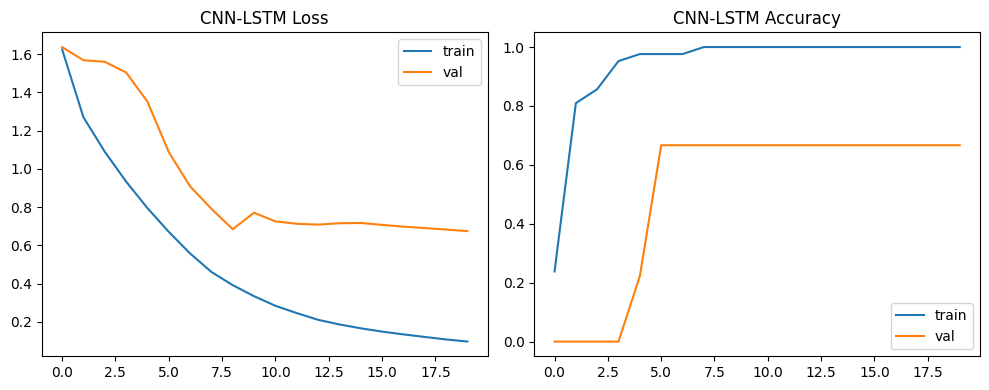

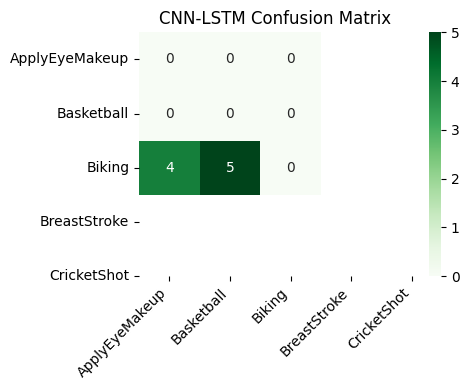

CNN-LSTM: acc=0.0%
Epoch 1/20
3/3 - 1s - 457ms/step - accuracy: 0.3333 - loss: 1.5453 - val_accuracy: 0.0000e+00 - val_loss: 1.9543
Epoch 2/20
3/3 - 0s - 136ms/step - accuracy: 0.6905 - loss: 0.9429 - val_accuracy: 0.6667 - val_loss: 1.2717
Epoch 3/20
3/3 - 0s - 46ms/step - accuracy: 0.7619 - loss: 0.6758 - val_accuracy: 0.5556 - val_loss: 1.1276
Epoch 4/20
3/3 - 0s - 33ms/step - accuracy: 0.9286 - loss: 0.4708 - val_accuracy: 0.5556 - val_loss: 1.1694
Epoch 5/20
3/3 - 0s - 33ms/step - accuracy: 1.0000 - loss: 0.3294 - val_accuracy: 0.5556 - val_loss: 1.2780
Epoch 6/20
3/3 - 0s - 32ms/step - accuracy: 1.0000 - loss: 0.2323 - val_accuracy: 0.5556 - val_loss: 1.3717
Epoch 7/20
3/3 - 0s - 32ms/step - accuracy: 1.0000 - loss: 0.1661 - val_accuracy: 0.5556 - val_loss: 1.4536
Epoch 8/20
3/3 - 0s - 32ms/step - accuracy: 1.0000 - loss: 0.1273 - val_accuracy: 0.5556 - val_loss: 1.5032
Epoch 9/20
3/3 - 0s - 32ms/step - accuracy: 1.0000 - loss: 0.1003 - val_accuracy: 0.5556 - val_loss: 1.5194
Epo

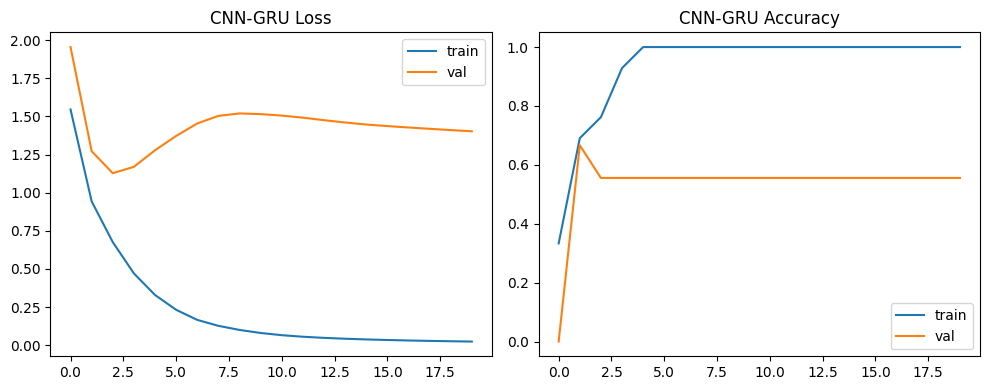

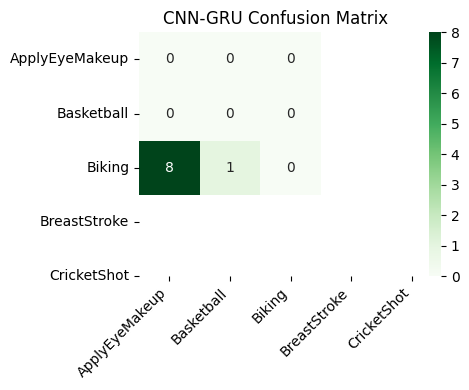

CNN-GRU: acc=0.0%
dataset_is_synthetic: False


In [29]:
def build_video_classifier(rnn_type):
    rnn_layer = layers.LSTM(32) if rnn_type == "LSTM" else layers.GRU(32)
    return models.Sequential([
        layers.Input(shape=(N_FRAMES, D)), rnn_layer,
        layers.Dense(16, activation="relu"),
        layers.Dense(len(UCF_CLASSES), activation="softmax"),
    ], name=f"CNN_{rnn_type}")

video_results = {}
for rnn_type in ["LSTM", "GRU"]:
    model = build_video_classifier(rnn_type)
    model.compile(optimizer=optimizers.Adam(1e-3), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    n_params = model.count_params()
    t0 = time.time()
    history = model.fit(feat_train, y_train_v, validation_data=(feat_val, y_val_v),
                         epochs=20, batch_size=16, verbose=2)
    train_time = time.time() - t0

    y_pred = np.argmax(model.predict(feat_test, verbose=0), axis=1)
    acc = accuracy_score(y_test_v, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test_v, y_pred, average="macro", zero_division=0)
    cm = confusion_matrix(y_test_v, y_pred)

    curve_path = FIG_DIR / f"video_{rnn_type}_curves.png"
    fig, ax = plt.subplots(1, 2, figsize=(10,4))
    ax[0].plot(history.history["loss"], label="train"); ax[0].plot(history.history["val_loss"], label="val")
    ax[0].set_title(f"CNN-{rnn_type} Loss"); ax[0].legend()
    ax[1].plot(history.history["accuracy"], label="train"); ax[1].plot(history.history["val_accuracy"], label="val")
    ax[1].set_title(f"CNN-{rnn_type} Accuracy"); ax[1].legend()
    plt.tight_layout(); plt.savefig(curve_path, dpi=150); plt.show()

    cm_path = FIG_DIR / f"video_{rnn_type}_confusion_matrix.png"
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", xticklabels=UCF_CLASSES, yticklabels=UCF_CLASSES)
    plt.title(f"CNN-{rnn_type} Confusion Matrix"); plt.xticks(rotation=45, ha="right")
    plt.tight_layout(); plt.savefig(cm_path, dpi=150); plt.show()

    video_results[rnn_type] = {
        "parameters": int(n_params), "training_time_sec": round(train_time, 2),
        "test_accuracy": round(float(acc)*100, 2), "macro_precision": round(float(prec)*100, 2),
        "macro_recall": round(float(rec)*100, 2), "macro_f1": round(float(f1)*100, 2),
        "confusion_matrix": cm.tolist(),
        "figures": {"curves": str(curve_path), "confusion_matrix": str(cm_path)},
    }
    print(f"CNN-{rnn_type}: acc={video_results[rnn_type]['test_accuracy']}%")

SUMMARY["video_understanding"] = {
    "dataset_is_synthetic": not used_real_ucf101,
    "classes": UCF_CLASSES,
    "videos_per_class": VIDEOS_PER_CLASS if used_real_ucf101 else 40,
    "n_frames": N_FRAMES, "feature_dim_D": int(D),
    "feature_tensor_shape_train": list(feat_train.shape),
    "sample_frames_figure": str(frame_fig_path),
    "results": video_results,
}
print("dataset_is_synthetic:", SUMMARY["video_understanding"]["dataset_is_synthetic"])

Epoch 1/25
55/55 - 4s - 69ms/step - accuracy: 0.1870 - loss: 2.2786 - val_accuracy: 0.2582 - val_loss: 2.1136
Epoch 2/25
55/55 - 1s - 9ms/step - accuracy: 0.3167 - loss: 1.8778 - val_accuracy: 0.3684 - val_loss: 1.6676
Epoch 3/25
55/55 - 0s - 9ms/step - accuracy: 0.4730 - loss: 1.3954 - val_accuracy: 0.6222 - val_loss: 1.0879
Epoch 4/25
55/55 - 1s - 9ms/step - accuracy: 0.7521 - loss: 0.8167 - val_accuracy: 0.8604 - val_loss: 0.6034
Epoch 5/25
55/55 - 1s - 9ms/step - accuracy: 0.9019 - loss: 0.4754 - val_accuracy: 0.9316 - val_loss: 0.3819
Epoch 6/25
55/55 - 1s - 10ms/step - accuracy: 0.9508 - loss: 0.3127 - val_accuracy: 0.9578 - val_loss: 0.2775
Epoch 7/25
55/55 - 1s - 11ms/step - accuracy: 0.9717 - loss: 0.2240 - val_accuracy: 0.9753 - val_loss: 0.2030
Epoch 8/25
55/55 - 1s - 10ms/step - accuracy: 0.9820 - loss: 0.1710 - val_accuracy: 0.9804 - val_loss: 0.1631
Epoch 9/25
55/55 - 1s - 11ms/step - accuracy: 0.9880 - loss: 0.1355 - val_accuracy: 0.9884 - val_loss: 0.1287
Epoch 10/25
55

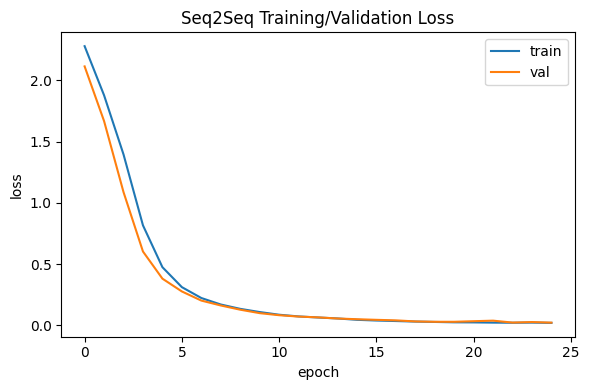

Seq2Seq: token_acc=99.78% seq_acc=98.67%


In [33]:
def seq2seq_experiment(n_samples=5000,seq_len=6,vocab_max=9):
    rng=np.random.RandomState(SEED)
    START,END=vocab_max+1,vocab_max+2
    vocab_size=vocab_max+3

    X=rng.randint(1,vocab_max+1,size=(n_samples,seq_len))
    Y=X[:,::-1]
    dec_in=np.concatenate([np.full((n_samples,1),START),Y[:,:-1]],axis=1)
    dec_target=Y

    n_train=int(0.7*n_samples)
    n_val=int(0.15*n_samples)
    splits={"train":slice(0,n_train),"val":slice(n_train,n_train+n_val),"test":slice(n_train+n_val,n_samples)}

    embed_dim,units=32,64
    enc_in=layers.Input(shape=(seq_len,))
    enc_emb=layers.Embedding(vocab_size,embed_dim)(enc_in)
    _,state_h,state_c=layers.LSTM(units,return_state=True)(enc_emb)

    dec_input=layers.Input(shape=(seq_len,))
    dec_emb=layers.Embedding(vocab_size,embed_dim)(dec_input)
    dec_out=layers.LSTM(units,return_sequences=True)(dec_emb,initial_state=[state_h,state_c])
    output=layers.Dense(vocab_size,activation="softmax")(dec_out)

    model=models.Model([enc_in,dec_input],output,name="Seq2Seq")
    model.compile(optimizer=optimizers.Adam(1e-3),loss="sparse_categorical_crossentropy",metrics=["accuracy"])

    t0=time.time()
    history=model.fit(
        [X[splits["train"]],dec_in[splits["train"]]],
        dec_target[splits["train"]],
        validation_data=(
            [X[splits["val"]],dec_in[splits["val"]]],
            dec_target[splits["val"]]
        ),
        epochs=25,batch_size=64,verbose=2
    )
    train_time=time.time()-t0

    loss_path=FIG_DIR/"seq2seq_loss.png"
    plt.figure(figsize=(6,4))
    plt.plot(history.history["loss"],label="train")
    plt.plot(history.history["val_loss"],label="val")
    plt.title("Seq2Seq Training/Validation Loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(loss_path,dpi=150)
    plt.show()

    test_pred=model.predict([X[splits["test"]],dec_in[splits["test"]]],verbose=0)
    pred_tokens=np.argmax(test_pred,axis=-1)
    target_tokens=dec_target[splits["test"]]

    token_acc=float((pred_tokens==target_tokens).mean())
    seq_acc=float((pred_tokens==target_tokens).all(axis=1).mean())

    examples=[]
    for i in range(5):
        examples.append({
            "input":X[splits["test"]][i].tolist(),
            "predicted_output":pred_tokens[i].tolist(),
            "true_output":target_tokens[i].tolist()
        })

    result={
        "n_samples":n_samples,
        "seq_len":seq_len,
        "integer_range":[1,vocab_max],
        "train_val_test_split":[n_train,n_val,n_samples-n_train-n_val],
        "encoder":"Embedding(32) -> LSTM(64), return_state=True",
        "decoder":"Embedding(32) -> LSTM(64, return_sequences=True) + Dense(softmax), teacher forcing",
        "training_time_sec":round(train_time,2),
        "token_accuracy":round(token_acc*100,2),
        "sequence_accuracy":round(seq_acc*100,2),
        "final_train_loss":round(float(history.history["loss"][-1]),4),
        "final_val_loss":round(float(history.history["val_loss"][-1]),4),
        "examples":examples,
        "loss_figure":str(loss_path)
    }

    print(f"Seq2Seq: token_acc={result['token_accuracy']}% seq_acc={result['sequence_accuracy']}%")
    return result

SUMMARY["seq2seq"]=seq2seq_experiment()